# TFM : Título del TFM
### Autores:
- ####  Adrian
- ####  Carlos Mendívil Gómez
- ####  Guillermo
- ####  Jose






#### Descripcion:

#### Carga de datos
Tres opciones:
- Webscrapping
- API
- csv iniciales

In [ ]:
#librerias
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import requests
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import re
from io import StringIO
from IPython.display import Markdown, display

**Opcion 1 (La mas probable seguro):** cargamos datos antiguos y datos actuales para identificar que inmuebles se han vendido y asi crear nuestra columna dependiente y la variable objetivo. Uso de Red neuronal para predecir futuros pisos al automatizar la recogida de datos. Opciones de modelo:

| Modelo                | Pros                                            | Contras                                          |
| --------------------- | ----------------------------------------------- | ------------------------------------------------ |
| **FT-Transformer**    | SOTA, mejor que MLP, usa atención, rápido       | Necesita algo de tuning, menos común que XGBoost |
| **TabNet**            | Selección automática de features, interpretable | Lento de entrenar, difícil de converger a veces  |
| **Red densa (MLP)**   | Rápido, fácil de implementar                    | Menor rendimiento sin mucho tuning               |
| **SAINT / MLP-Mixer** | Nuevas ideas, muy potente si hay mucho dato     | Más experimental, menos soporte y recursos       |

  Métricas que se pueden usar:

  - ROC-AUC: mejor que accuracy si hay desbalance.
  - Precision@k: útil si quieres saber si los mejores pisos realmente se venden.
  - SHAP: interpretabilidad (FT-Transformer tiene soporte parcial).

Tras ello crear un modelo de IA generativa que pueda aconsejar al cliente. Pasos para ello:
  - 1 - Entrenar y guardar el modelo de clasificación con probabilidad de venta.
Guardar la tabla de resultados con prob_vendido.
  - 2 - Función de parsing del texto del cliente a filtros (NLU).
  - 3 -Filtro sobre el dataset para quedarte con “buenas ofertas” + matching con las preferencias del cliente.
  - 4 -LLM que toma el texto del cliente + ofertas y genera una recomendación.

(Opcional) UI: chatbot o aplicación. (No creo que de tiempo pero por soñar...)


**Opcion 2:** A partir de los datos más actuales determinamos las variables independientes mas importantes para definirlas como parametros a la hora de representar cada una de las filas (los pisos) en un hiperplano (como el clustering) y así poder clasificar cual de ellos es mejor. Luego continuariamos igual con lo de la IA generativa.

------------------
Como opcional si aparece una columna con opiniones o criticas podriamos realizar clasificaciones de texto para cambiar la columna con un int del 1 al 5 segun reseñas positivas o reseñas negativas.

In [ ]:
# URLs base
repo_html_url = "https://github.com/guille1006/TFM/tree/main/Idealista/datos"
raw_base = "https://raw.githubusercontent.com/guille1006/TFM/main/Idealista/datos/"

# Obtener lista de archivos .csv del repositorio
html = requests.get(repo_html_url).text
csv_files = sorted(set(re.findall(r'datos_pag_\d+\.csv', html)))

if not csv_files:
    raise ValueError("No se encontraron archivos CSV en el repositorio.")

# Estructuras para almacenar resultados
dataframes = []
column_sets = {}
errores = []
logs = []

# Procesamiento de archivos
for file in csv_files:
    file_url = raw_base + file
    try:
        resp = requests.get(file_url)
        resp.raise_for_status()
        content = resp.text.strip()

        if not content:
            errores.append({"archivo": file, "error": "Archivo vacío"})
            continue

        df = pd.read_csv(StringIO(content))

        if df.empty:
            errores.append({"archivo": file, "error": "Sin datos"})
            continue

        dataframes.append((file, df))
        column_sets[file] = set(df.columns)

    except pd.errors.EmptyDataError:
        errores.append({"archivo": file, "error": "EmptyDataError"})
    except Exception as e:
        errores.append({"archivo": file, "error": str(e)})

# Revisión de estructura de columnas
all_columns = set()
for cols in column_sets.values():
    all_columns.update(cols)

estructura_columnas = []
base_columns = column_sets[list(column_sets.keys())[0]] if column_sets else set()

for file, cols in column_sets.items():
    n_rows = next((len(df) for f, df in dataframes if f == file), None)
    if cols != base_columns:
        missing = sorted(base_columns - cols)
        extra = sorted(cols - base_columns)
        estructura_columnas.append({
            "archivo": file,
            "filas": n_rows,
            "faltan_columnas": missing,
            "columnas_extra": extra
        })

# Normalización de DataFrames
normalized_dfs = []
for file, df in dataframes:
    current_cols = set(df.columns)
    missing_cols = all_columns - current_cols

    for col in missing_cols:
        df[col] = pd.NA

    df = df.reindex(columns=sorted(all_columns))
    normalized_dfs.append(df)

# Concatenación final
combined_df = pd.concat(normalized_dfs, ignore_index=True, sort=False)

# Registro final para auditoría o logging externo
resumen_proceso = {
    "archivos_totales_detectados": len(csv_files),
    "archivos_exitosos": len(dataframes),
    "archivos_con_errores": errores,
    "columnas_base": sorted(base_columns),
    "total_columnas_combinadas": len(all_columns),
    "discrepancias_columnas": estructura_columnas,
    "filas_totales": combined_df.shape[0],
    "columnas_finales": sorted(combined_df.columns.tolist())
}
display(Markdown(f"""
- **Archivos cargados correctamente:** {resumen_proceso["archivos_exitosos"]}
- **Archivos con errores (vacíos o corruptos):** {len(resumen_proceso["archivos_con_errores"])}
- **Archivos con columnas distintas:** {len(resumen_proceso["discrepancias_columnas"])}
"""))

/tmp/ipython-input-1871698576.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(normalized_dfs, ignore_index=True, sort=False)



- **Archivos cargados correctamente:** 434
- **Archivos con errores (vacíos o corruptos):** 64
- **Archivos con columnas distintas:** 384


#### EDA/ limpieza de datos (si es necesario)

In [ ]:
df_datos = combined_df.copy()
print(df_datos.shape)
df_datos.describe()

(21671, 49)


,bathrooms,latitude,longitude,numPhotos,parkingSpace.parkingSpacePrice,price,priceByArea,priceInfo.price.amount,priceInfo.price.priceDropInfo.formerPrice,priceInfo.price.priceDropInfo.priceDropPercentage,priceInfo.price.priceDropInfo.priceDropValue,propertyCode,rooms,size
count,21671.000000,21671.000000,21671.000000,21671.000000,328.000000,2.167100e+04,21671.000000,2.167100e+04,2.189000e+03,2189.000000,2189.000000,2.167100e+04,21671.000000,21671.000000
mean,2.331180,40.430773,-3.717232,27.546998,31857.310976,8.780367e+05,5062.095289,8.780367e+05,5.839238e+05,4.602101,27645.709456,1.073407e+08,3.160260,212.106668
std,1.564254,0.117400,0.169047,19.495802,21241.635501,1.193534e+06,3563.798676,1.193534e+06,5.860253e+05,3.102487,43945.555918,4.672519e+06,1.693311,1764.326158
min,0.000000,40.010758,-4.494274,0.000000,60.000000,1.100000e+04,17.000000,1.100000e+04,3.200000e+04,1.000000,1000.000000,4.600250e+05,0.000000,11.000000
25%,1.000000,40.385524,-3.771257,14.000000,15000.000000,2.550000e+05,2561.000000,2.550000e+05,2.390000e+05,3.000000,10000.000000,1.075127e+08,2.000000,76.000000
50%,2.000000,40.425758,-3.698546,24.000000,30000.000000,4.590000e+05,3828.000000,4.590000e+05,3.830000e+05,4.000000,15000.000000,1.083417e+08,3.000000,115.000000
75%,3.000000,40.465263,-3.653455,37.000000,40000.000000,1.000000e+06,6726.000000,1.000000e+06,7.200000e+05,6.000000,29500.000000,1.086816e+08,4.000000,213.000000
max,29.000000,41.106928,-3.071336,190.000000,100000.000000,1.850000e+07,37143.000000,1.850000e+07,7.500000e+06,45.000000,755200.000000,1.089514e+08,58.000000,150000.000000


#### Eliminar duplicados

In [ ]:
# Eliminamos duplicados
df_datos = df_datos.drop_duplicates()
print(df_datos.shape)

(17461, 49)


#### Valores nulos

In [ ]:
df_nulls = (
    df_datos.isnull().sum()
    .to_frame(name="Nulos")
    .query("Nulos > 0")
    .assign(
        Valores_unicos=lambda df: df_datos[df.index].nunique(dropna=False)
    )
    .sort_values(by="Nulos", ascending=False)
    .reset_index()
    .rename(columns={"index": "Columna"})
)

# Mostrar resumen limpio
display(Markdown("### Columnas con valores nulos"))
display(df_nulls)

### Columnas con valores nulos

,Columna,Nulos,Valores_unicos
0,parkingSpace.parkingSpacePrice,17192,58
1,priceInfo.price.priceDropInfo.priceDropPercentage,15687,25
2,priceInfo.price.priceDropInfo.formerPrice,15687,635
3,priceInfo.price.priceDropInfo.priceDropValue,15687,220
4,newDevelopmentFinished,15678,3
5,detailedType.subTypology,11193,14
6,highlight.groupDescription,10813,4
7,parkingSpace.isParkingSpaceIncludedInPrice,9617,3
8,parkingSpace.hasParkingSpace,9617,2
9,neighborhood,6979,196


| Estado | Columna                                             | Nulos  | Valores únicos |
| ------ | --------------------------------------------------- | ------ | -------------- |
| ✅      | `parkingSpace.parkingSpacePrice`                    | 17,192 | 58             |
| ✅      | `priceInfo.price.priceDropInfo.priceDropPercentage` | 15,687 | 25             |
| ✅      | `priceInfo.price.priceDropInfo.formerPrice`         | 15,687 | 635            |
| ✅      | `priceInfo.price.priceDropInfo.priceDropValue`      | 15,687 | 220            |
| ✅      | `newDevelopmentFinished`                            | 15,678 | 3              |
| ✅      | `detailedType.subTypology`                          | 11,193 | 14             |
| ✅      | `highlight.groupDescription`                        | 10,813 | 4              |
| ✅      | `parkingSpace.isParkingSpaceIncludedInPrice`        | 9,617  | 3              |
| ✅      | `parkingSpace.hasParkingSpace`                      | 9,617  | 2              |
| ✅      | `neighborhood`                                      | 6,979  | 196            |
| ❌      | `floor`                                             | 5,028  | 41             |
| ✅      | `exterior`                                          | 4,944  | 3              |
| ✅      | `hasLift`                                           | 4,668  | 3              |
| ✅      | `externalReference`                                 | 4,597  | 11,977         |
| ❌      | `district`                                          | 2,429  | 271            |
| ✅      | `status`                                            | 385    | 4              |
| ✅      | `thumbnail`                                         | 272    | 16,729         |
| ✅      | `description`                                       | 27     | 16,047         |



In [ ]:
df_datos_1 = df_datos.copy()

In [ ]:
# priceInfo

# parkingSpacePrice
df_datos_1['parkingSpace.parkingSpacePrice'] = df_datos_1['parkingSpace.parkingSpacePrice'].fillna(0.0)

#priceDropPercentage
df_datos_1['priceInfo.price.priceDropInfo.priceDropPercentage'] = df_datos_1['priceInfo.price.priceDropInfo.priceDropPercentage'].fillna(0.0)

# priceDropValue
df_datos_1['priceInfo.price.priceDropInfo.priceDropValue'] = df_datos_1['priceInfo.price.priceDropInfo.priceDropValue'].fillna(0.0)

# formerPrice
df_datos_1.loc[df_datos_1['priceInfo.price.priceDropInfo.formerPrice'].isna(), 'priceInfo.price.priceDropInfo.formerPrice'] = \
df_datos_1.loc[df_datos_1['priceInfo.price.priceDropInfo.formerPrice'].isna(), 'priceInfo.price.amount']

#subtipology
df_datos_1['detailedType.subTypology'] = df_datos_1['detailedType.subTypology'].fillna(df_datos_1['detailedType.typology'])

#groupDescription
df_datos_1['highlight.groupDescription'] = df_datos_1['highlight.groupDescription'].fillna("No_Destacado")

In [ ]:
df_datos_2 = df_datos_1.copy()

In [ ]:
#unknown

#newDevelopmentFinished
df_datos_2['newDevelopmentFinished'] = df_datos_2['newDevelopmentFinished'].fillna('unknown')

#externalReference
df_datos_2['externalReference'] = df_datos_2['externalReference'].fillna('unknown')

#thumbnail
df_datos_2['thumbnail'] = df_datos_2['thumbnail'].fillna('unknown')

#description
df_datos_2['description'] = df_datos_2['description'].fillna('unknown')

In [ ]:
df_datos_3 = df_datos_2.copy()

In [ ]:
# Lista de columnas booleanas a convertir
bool_cols = [
    'exterior',
    'hasLift',
    'parkingSpace.hasParkingSpace',
    'parkingSpace.isParkingSpaceIncludedInPrice',
]

df_datos_3[bool_cols] = (
    df_datos_3[bool_cols]
    .fillna(False)
    .astype(int)
)

/tmp/ipython-input-966229322.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [ ]:
df_datos_3["size"].value_counts()

,count
size,
80.0,272
70.0,241
60.0,229
90.0,226
75.0,219
...,...
892.0,1
1700.0,1
1360.0,1


In [ ]:
df_datos_4 = df_datos_3.copy()

In [ ]:
#floor
features = ['price', 'size', 'rooms', 'bathrooms', 'hasLift', 'priceByArea', 'latitude', 'longitude']

# Limpieza inicial
df_datos_4['floor'] = df_datos_4['floor'].replace('bj', '0')
df_datos_4.loc[df_datos_4['floor'].isna() & df_datos_4['propertyType'].isin(['chalet', 'countryHouse']), 'floor'] = 'house'

df_datos_4['floor'] = (
    df_datos_4['floor'].astype(str).str.lower().str.strip()
    .replace({'no': 'house', 'ss': '-1', 'sm': '-1', 'st': '0', 'en': '0', '+1': '1'})
    .apply(lambda x: 'house' if x == 'house' else (str(int(float(x))) if x.replace('.', '', 1).lstrip('-').isdigit() else np.nan))
)

valid_floors = [str(i) for i in range(-1, 31)]
df_datos_4.loc[~df_datos_4['floor'].isin(valid_floors + ['house']), 'floor'] = np.nan

# Preparar datos para modelo (pisos, floor no nulo y no 'house')
df_train = df_datos_4[df_datos_4['floor'].notna() & (df_datos_4['floor'] != 'house')].dropna(subset=features)
df_train['floor'] = df_train['floor'].astype(int)

X = df_train[features]
y = df_train['floor']

# Filtrar clases con al menos 2 muestras para evitar error en stratify
valid_classes = y.value_counts()[lambda x: x >= 2].index
X, y = X[y.isin(valid_classes)], y[y.isin(valid_classes)]

# Split con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Entrenar Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluar
y_pred = model.predict(X_test)
print(f"Accuracy del modelo de imputación de 'floor': {accuracy_score(y_test, y_pred):.4f}")

# Baseline (clase mayoritaria)
most_common = y_train.value_counts().idxmax()
baseline_acc = (y_test == most_common).mean()
print(f"Baseline (predecir siempre '{most_common}'): {baseline_acc:.4f}")

# Predecir pisos faltantes (no chalet ni countryHouse)
df_pred = df_datos_4[df_datos_4['floor'].isna() & ~df_datos_4['propertyType'].isin(['chalet', 'countryHouse'])].dropna(subset=features)
df_datos_4.loc[df_pred.index, 'floor'] = model.predict(df_pred[features]).astype(str)

# Agrupar pisos altos
df_datos_4['floor'] = df_datos_4['floor'].astype(str).replace({str(i): '15+' for i in range(15, 31)})

Accuracy del modelo de imputación de 'floor': 0.3639
Baseline (predecir siempre '1'): 0.2181


In [ ]:
# Status

# Limpiar columnas para el RandomForest no reviente la RAM
cols_to_drop = [
    'url', 'externalReference', 'thumbnail', 'propertyCode',
    'description', 'suggestedTexts.title', 'suggestedTexts.subtitle',
    'notes', 'address'
]
df_prep = df_datos_4.copy()
df_prep = df_prep.drop(columns=[col for col in cols_to_drop if col in df_prep.columns])

cat_cols = df_prep.select_dtypes(include=['object', 'bool']).columns
for col in cat_cols:
    if df_prep[col].nunique() > 50:
        df_prep = df_prep.drop(columns=col)

# Separar datos con y sin status
df_labeled = df_prep[df_prep['status'].notna()].copy()
df_unlabeled = df_prep[df_prep['status'].isna()].copy()

# 1. Variables numéricas
num_cols = df_labeled.select_dtypes(include=['float64', 'int64']).columns

imputer = SimpleImputer(strategy='median')
df_labeled[num_cols] = imputer.fit_transform(df_labeled[num_cols])
df_unlabeled[num_cols] = imputer.transform(df_unlabeled[num_cols])

# 2. Variables categóricas
cat_cols = df_labeled.select_dtypes(include=['object', 'bool']).drop(columns=['status']).columns

# Reemplazar NaNs con string fijo y asegurar tipo string
df_labeled[cat_cols] = df_labeled[cat_cols].fillna('missing').astype(str)
df_unlabeled[cat_cols] = df_unlabeled[cat_cols].fillna('missing').astype(str)

# One-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(df_labeled[cat_cols])
X_cat_unlabeled = encoder.transform(df_unlabeled[cat_cols])

# 3. Combinar variables numéricas y categóricas
X_num = df_labeled[num_cols].values
X_unlabeled_num = df_unlabeled[num_cols].values

X = np.hstack((X_num, X_cat))
X_unlabeled = np.hstack((X_unlabeled_num, X_cat_unlabeled))

# 4. Entrenar modelo y predecir
y = df_labeled['status']
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)

predicted_status = clf.predict(X_unlabeled)

# 5. Imputar los valores predichos
df_datos_4.loc[df_datos_4['status'].isna(), 'status'] = predicted_status

/tmp/ipython-input-2159629258.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_unlabeled[cat_cols] = df_unlabeled[cat_cols].fillna('missing').astype(str)


In [ ]:
# Comprobar si quedan nulos
print(df_datos_4["status"].value_counts(dropna=False))

status
good              13438
renew              2240
newdevelopment     1783
Name: count, dtype: int64


In [ ]:
df_datos_5 = df_datos_4.copy()

In [ ]:
#ubicacion

In [ ]:
# Comprobacion Nulos
df_datos_5.isna().sum().sum()

np.int64(9408)

### Estudiar formato variables

In [ ]:
df_datos_6 = df_datos_5.copy()

In [ ]:
# Obtener información de las columnas
variables = list(df_datos_6.columns)

info_types = pd.DataFrame(
    {"Tipo de columna": df_datos_5.dtypes, "Suma de valores únicos": df_datos_5.nunique()}
)

info_types

,Tipo de columna,Suma de valores únicos
address,object,7192
bathrooms,int64,18
country,object,1
description,object,16047
detailedType.subTypology,object,15
detailedType.typology,object,3
district,object,270
exterior,int64,2
externalReference,object,11977
floor,object,18


In [ ]:
#Variables a descartar
cols_to_drop = [
    'province',
    'country',
    'notes',
    'highlight.groupDescription',
    'thumbnail',
    'externalReference',
    'url',
    'description',
    "operation",
    "priceInfo.price.currencySuffix",
    "priceInfo.price.amount",
    "topNewDevelopment",

]

#Columnas a considerar:
#propertyCode, numPhotos, suggestedTexts.subtitle, 'suggestedTexts.title'

# Eliminarlas del DataFrame
df_datos_6.drop(columns=cols_to_drop, inplace=True)

In [ ]:
df_datos_7 =df_datos_6.copy()

In [ ]:
#Categoricas
#Ya object = floor, propertyType, address, municipality, district, detailedType.typology, detailedType.subTypology, suggestedTexts.subtitle, suggestedTexts.title, neighborhood
categorical_cols = [
    'floor',
    'propertyType',
    'address',
    'municipality',
    'district',
    'detailedType.typology',
    'detailedType.subTypology',
    'suggestedTexts.subtitle',
    'suggestedTexts.title',
    'status',
    'neighborhood'
]

# Convertir a tipo categórico
df_datos_6[categorical_cols] = df_datos_6[categorical_cols].astype('object')

In [ ]:
df_datos_7 = df_datos_6.copy()

In [ ]:
#Numericas
#Ya numérica = numPhotos, price, size, exterior, rooms, bathrooms, latitude, longitude, hasLift, priceByArea, parkingSpace.hasParkingSpace, parkingSpace.isParkingSpaceIncludedInPrice
#priceInfo.price.priceDropInfo.formerPrice, priceInfo.price.priceDropInfo.priceDropValue, priceInfo.price.priceDropInfo.priceDropPercentage, parkingSpace.parkingSpacePrice

#Binarias a convertir = showAddress, hasVideo, status, newDevelopment, hasPlan, has3DTour, has360, hasStaging, topNewDevelopment, topPlus

#Revisar priceInfo.price.amount
# Columnas numéricas ya numéricas
numeric_cols = [
    'price',
    'size',
    'rooms',
    'bathrooms',
    'latitude',
    'longitude',
    'priceByArea',
    'priceInfo.price.priceDropInfo.formerPrice',
    'priceInfo.price.priceDropInfo.priceDropValue',
    'priceInfo.price.priceDropInfo.priceDropPercentage',
    'parkingSpace.parkingSpacePrice'
]

binary_cols = [
    'showAddress',
    'hasVideo',
    'newDevelopment',
    'hasPlan',
    'has3DTour',
    'has360',
    'hasStaging',
    'topPlus'
]

for col in binary_cols:
    df_datos_7[col] = df_datos_7[col].astype(str).str.strip().map({'True': 1, 'False': 0})


In [ ]:
df_datos_8 = df_datos_7.copy()

#var_obj = df_datos_8['vendido']
#df_datos_8.drop(columns=["vendido"], inplace=True)

#Establecemos las variables numéricas y las categóricas
variables_numericas = df_datos_8.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

variables_categoricas = df_datos_8.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

#### Estudio de las variables categoricas

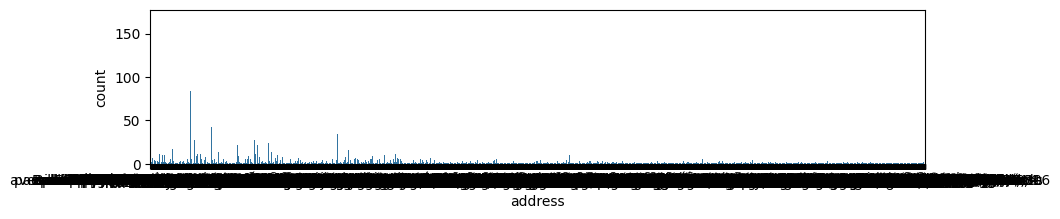

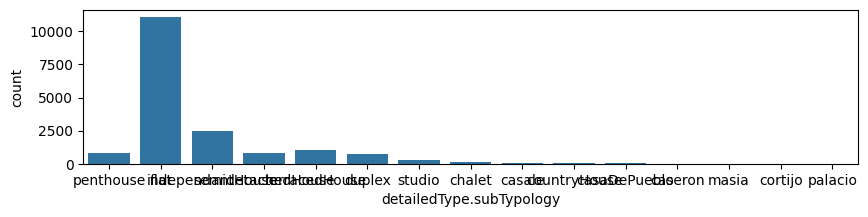

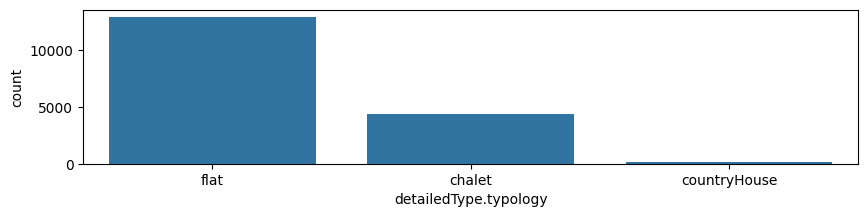

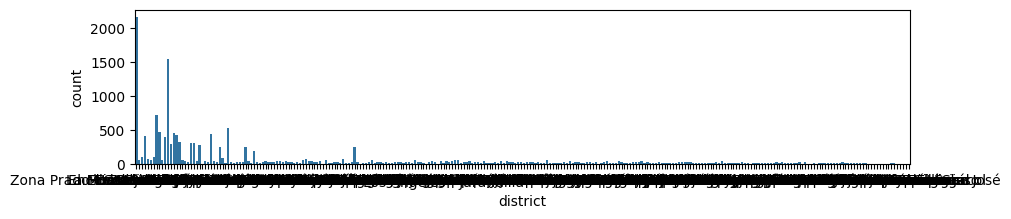

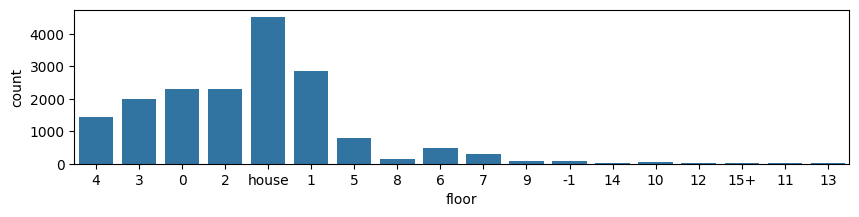

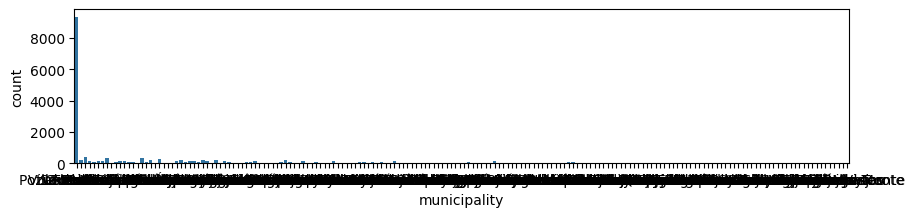

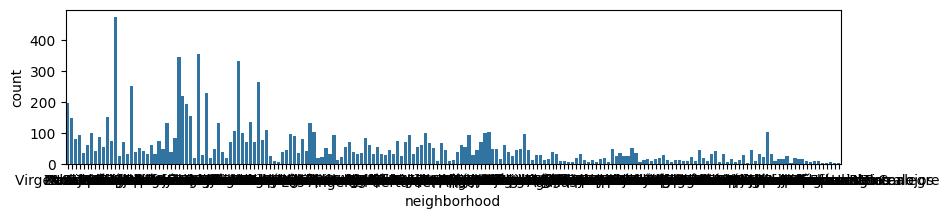

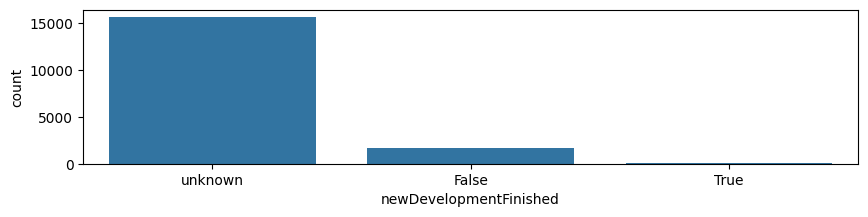

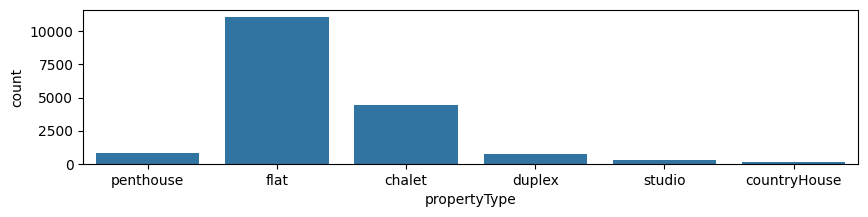

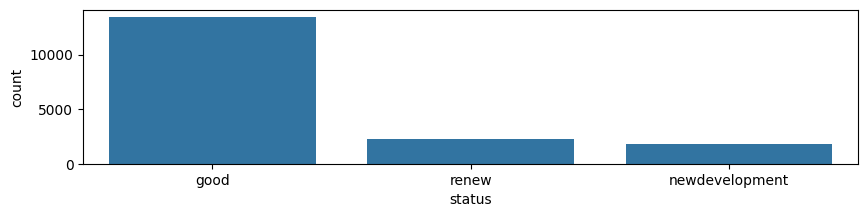

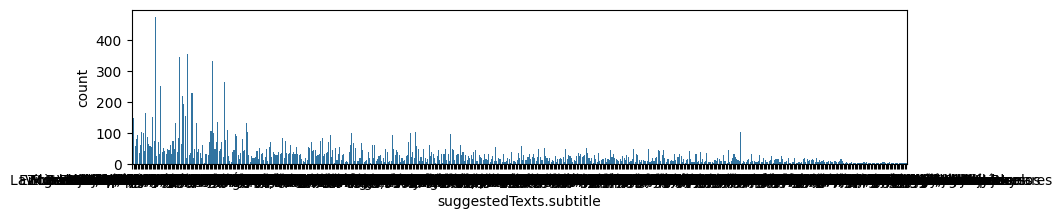

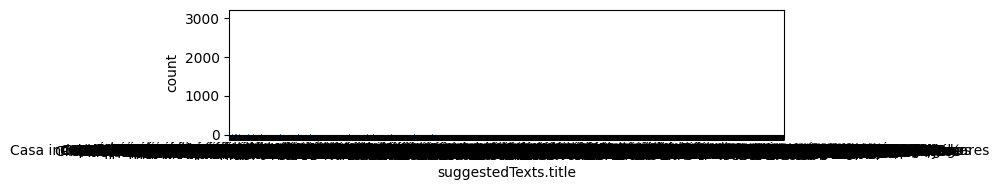

In [ ]:
#Estudio variables categóricas
for col in variables_categoricas:
    plt.figure(figsize=(10,2))
    sns.countplot(data=df_datos_8, x=col)

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# Mostrar la relación entre subtypology y typology con el conteo
relacion = df_datos_8.groupby(['detailedType.typology', 'detailedType.subTypology']).size().reset_index(name='count')

# Ordenar para mejor visualización
relacion = relacion.sort_values(['detailedType.typology', 'count'], ascending=[True, False])

print(relacion)

   detailedType.typology detailedType.subTypology  count
1                 chalet         independantHouse   2467
3                 chalet            terracedHouse   1012
2                 chalet        semidetachedHouse    808
0                 chalet                   chalet    114
8           countryHouse             countryHouse     71
4           countryHouse             casaDePueblo     39
5           countryHouse                   casale     20
6           countryHouse                  caseron      4
7           countryHouse                  cortijo      2
9           countryHouse                    masia      2
10          countryHouse                  palacio      2
12                  flat                     flat  11079
13                  flat                penthouse    810
11                  flat                   duplex    713
14                  flat                   studio    318


In [ ]:
"""
for col in variables_categoricas:
    plt.figure(figsize=(10, 2))
    sns.countplot(data=df_datos_8, x=col, hue=var_obj)

plt.tight_layout()
plt.savefig('vc.png', format='png', dpi=300)
plt.show()
plt.close()
"""

#### Estudio de las variables numéricas

In [ ]:
#Estudio variables numéricas
df_datos_8[variables_numericas].describe().T

In [ ]:
# Graficamos las distribuciones de las variables numéricas
for col in variables_numericas:
    plt.figure(figsize=(10, 2))
    sns.histplot(data=df_datos_8, x=col)

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
"""
for col in variables_numericas:
    plt.figure(figsize=(10, 2))
    sns.histplot(data=df_datos_8, x=col, hue=var_obj)

plt.savefig('vn.png', format='png', dpi=300)
plt.show()
plt.close()
"""

### Clustering

Evaluando diferentes combinaciones de Clustering.
Puntos a tener en cuenta. OHE agrega más dimensionalidad -> más datos, complejidad de procesamiento es mayor.
Para realizar Clustering utilizaremos diferentes variantes y observaremos resultados, descartando las que no sirvan:
Clusterings a probar:
1. District(Object), Room(num), Bathroom (num) -> utilizando OHE+KMeans
2. District(Object), Room(num), Bathroom (num) -> utilizando K-Prototypes
3. Price(num), District(Object), Room(num), Bathroom (num) -> utilizando K-Prototypes
4. priceByArea(num), District(Object), Room(num), Bathroom (num) -> utilizando K-Prototypes

---




In [ ]:
# ONE HOT ENCODE para district
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
district_encoded = ohe.fit_transform(df_datos_8[['district']])
encoded_df = pd.DataFrame(district_encoded, columns=ohe.get_feature_names_out(['district']))

# df_cluster = df_datos_8.drop(columns="district").reset_index(drop=True)

## Clustering Generico

In [ ]:
# Normalizamos valores. Hay que valorar si es útil para nuestra variable objetiva
numerical_cols = df_datos_8.select_dtypes(include=["float64"])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(numerical_cols)

X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=numerical_cols.columns)

# X_num_scaled_df.head()
df_cluster = pd.concat([X_num_scaled_df, encoded_df], axis=1)

In [ ]:
# PODEMOS AGREGAR UN PCA OPCIONAL AQUI

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(df_cluster)

from sklearn.metrics import silhouette_score

score = silhouette_score(df_cluster, clusters)
print(f"Silhouette Score: {score:2f}")

import matplotlib.pyplot as plt

plt.scatter(df_cluster.values[:, 0], df_cluster.values[:, 1], c=clusters, cmap='viridis')
plt.title("Clusters visualizados en 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()


## Clustering especifico por variables: district

#### Diseñado del modelo DL

In [ ]:
df_datos_9 = df_datos_8.copy()

In [ ]:
X = df_datos_9.drop("price", axis=1)
y = df_datos_9["price"]

variables_numericas = df_datos_9.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

variables_numericas_sin_price = variables_numericas.remove("price")

variables_categoricas = df_datos_9.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

#Separar numericas y categoricas
X_num = df_datos_9[variables_numericas_sin_price].copy()
X_cat = df_datos_9[variables_categoricas].copy()

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Codificar categóricas como one-hot (más fácil al principio)
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# Combinar
X_preprocessed = np.concatenate([X_num_scaled, X_cat_encoded.values], axis=1)

# Separar datos
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

##### Modelo secuencial ANN Binaria

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

model = tf.keras.models.Sequential()

# Capa 1
model.add(layers.Dense(64, activation='relu',
                       input_shape=(x_train.shape[1],),
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 2
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 3
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 4
model.add(layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))

# Capa de salida para clasificación binaria
model.add(layers.Dense(1, activation='sigmoid'))

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Entrenamiento
batch_size = 64
model.fit(x_train,
          y_train,
          epochs=200,
          batch_size=batch_size,
          validation_split=0.2,
          verbose=1,
          callbacks=[
              tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
          ])

# Evaluación
results = model.evaluate(x_test, y_test, verbose=1)
print(f'\nTest Loss: {results[0]:.4f} | Accuracy: {results[1]:.4f} | AUC: {results[2]:.4f} | Precision: {results[3]:.4f} | Recall: {results[4]:.4f}')

In [ ]:
# Guardar probabilidad de venta
df_features = preprocessor.transform(X)
df['prob_vendido'] = model.predict(df_features).flatten()

# Opcional: guardar
df.to_csv("viviendas_con_predicciones.csv", index=False)
model.save("modelo_clasificador.h5")

##### Modelo secuencial ANN Regression

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

model = tf.keras.models.Sequential()

# Capa 1
model.add(layers.Dense(64, activation='relu',
                       input_shape=(x_train.shape[1],),
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 2
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 3
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 4
model.add(layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))

# Capa de salida para regresión (sin activación)
model.add(layers.Dense(1))

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', 'mse']
)

# Entrenamiento
batch_size = 64
model.fit(x_train,
          y_train,
          epochs=200,
          batch_size=batch_size,
          validation_split=0.2,
          verbose=1,
          callbacks=[
              tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
          ])

# Evaluación
results = model.evaluate(x_test, y_test, verbose=1)
print(f'\nTest Loss: {results[0]:.4f} | MAE: {results[1]:.4f} | MSE: {results[2]:.4f}')


##### Ft-transform (Vemos cual da mejor resultado entre los dos para usarlo despues)

In [ ]:
#!pip install pytorch-tabular

from pytorch_tabular import TabularModel
from pytorch_tabular.models.ft_transformer import FTTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import pandas as pd

# Detectar variables
target = "vendido"
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
continuous_cols = df.select_dtypes(include=["int64", "float64"]).drop(columns=[target]).columns.tolist()

# Configuración del dataset
data_config = DataConfig(
    target=target,
    continuous_cols=continuous_cols,
    categorical_cols=categorical_cols,
    normalize_continuous_features=True,
)

# Configuración del modelo FT-Transformer
model_config = FTTransformerConfig(
    task="classification",
    learning_rate=1e-3,
    metrics=["accuracy", "auc"],
    num_attention_heads=4,
    transformer_hidden_dim=64,
    input_embed_dim=32,
    num_layers=4,
)

trainer_config = TrainerConfig(
    auto_lr_find=True,
    batch_size=64,
    max_epochs=100,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    gpus=0  # Usa 1 si tienes GPU en Colab
)

# Construir y entrenar el modelo
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    trainer_config=trainer_config,
)

tabular_model.fit(df)

# Predecir y guardar probabilidad de venta
pred_df = tabular_model.predict(df)
df['prob_vendido'] = pred_df['prediction_probability'].values
df['clasificacion'] = df['prob_vendido'].apply(
    lambda x: "Excelente" if x > 0.8 else ("Buena" if x > 0.6 else "Mala")
)

# Guardar
df.to_csv("viviendas_con_fttransformer.csv", index=False)

#### IA Generativa (Ejemplo, habra que cambiarlo segun los datos)

In [ ]:
#IA
preferencias = {
    'zona': 'Centro',
    'habitaciones_min': 2,
    'precio_max': 300000
}

df_recomendadas = df[
    (df['zona'] == preferencias['zona']) &
    (df['habitaciones'] >= preferencias['habitaciones_min']) &
    (df['precio'] <= preferencias['precio_max']) &
    (df['clasificacion'].isin(['Buena', 'Excelente']))
]

In [ ]:
pip install selenium

In [ ]:
import pandas as pd
from pandas import json_normalize

# Lista de viviendas dentro del JSON
viviendas = data_json["elementList"]

# Usamos json_normalize con sep='.' para que las claves anidadas se aplanen con ese separador
df = json_normalize(viviendas, sep='.')

# Mostrar columnas finales del DataFrame
print("Columnas limpias del DataFrame:")
df